# Mini-BLIP2 Training Notebook

这个 notebook 复现一个轻量版 BLIP-2 图像描述生成流程：默认读取 Flickr8k 当前目录中的全部图片，冻结 CLIP 视觉编码器和 OPT 语言模型，只训练中间的 Mini Q-Former 与投影层。

## 1. 环境检查

如果缺少依赖，先在终端或 notebook 中执行：

```bash
pip install torch torchvision transformers pillow numpy tqdm matplotlib
```

In [25]:
import csv
import math
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer, CLIPImageProcessor, CLIPVisionModel, OPTForCausalLM

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.2.2+cu121
CUDA available: True


In [26]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'code':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
IMAGE_DIR_CANDIDATES = [DATA_DIR / 'Images', DATA_DIR]
IMAGE_DIR = next((path for path in IMAGE_DIR_CANDIDATES if path.exists() and any(path.glob('*.jpg'))), DATA_DIR / 'Images')
CAPTION_FILE = DATA_DIR / 'captions.txt'
OUTPUT_DIR = PROJECT_ROOT / 'code' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'num_images': None,  # None 表示读取 data/Images 中所有能匹配到 caption 的图片
    'val_images': None,  # None 时按 val_ratio 自动划分验证集
    'val_ratio': 0.1,
    'batch_size': 2,
    'num_workers': 0,
    'epochs': 1,
    'max_steps': None,  # 调试时可改成 20；完整训练可保持 None
    'lr': 2e-4,
    'weight_decay': 0.01,
    'max_text_length': 48,
    'caption_prompt': 'A photo of',
    'num_query_tokens': 16,
    'qformer_dim': 256,
    'qformer_layers': 2,
    'qformer_heads': 8,
    'vision_model': 'openai/clip-vit-base-patch32',
    'language_model': 'facebook/opt-125m',
    'checkpoint_path': OUTPUT_DIR / 'mini_blip2_flickr8k.pt',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('Image dir:', IMAGE_DIR)
print('Device:', device)

Project root: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main
Image dir: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main\data\Images
Device: cuda


## 2. 读取 Flickr8k 全部图片

`captions.txt` 中每张图片通常有 5 条 caption。这里默认读取 `data/Images` 中所有能匹配到 caption 的图片；如果只想调试小样本，可以把 `CONFIG['num_images']` 改成具体数字。

In [27]:
def load_flickr8k_records(caption_file, image_dir, num_images=None):
    captions_by_image = defaultdict(list)
    with open(caption_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_name = row['image'].strip()
            caption = row['caption'].strip()
            if image_name and caption:
                captions_by_image[image_name].append(caption)

    selected_images = []
    for image_name in captions_by_image:
        if (image_dir / image_name).exists():
            selected_images.append(image_name)
        if num_images is not None and len(selected_images) >= num_images:
            break

    records = []
    for image_name in selected_images:
        for caption in captions_by_image[image_name]:
            records.append({
                'image_name': image_name,
                'image_path': image_dir / image_name,
                'caption': caption,
            })
    return records, captions_by_image, selected_images


records, captions_by_image, selected_images = load_flickr8k_records(
    CAPTION_FILE,
    IMAGE_DIR,
    num_images=CONFIG['num_images'],
)

assert records, '没有读到数据，请确认 data/captions.txt 和 data/Images 是否存在。'
print(f'Images: {len(selected_images)}')
print(f'Caption samples: {len(records)}')
print(records[0])

Images: 8091
Caption samples: 40455
{'image_name': '1000268201_693b08cb0e.jpg', 'image_path': WindowsPath('E:/program_prject/vscode_python_project/论文复现/blip2-main/blip2-main/data/Images/1000268201_693b08cb0e.jpg'), 'caption': 'A child in a pink dress is climbing up a set of stairs in an entry way .'}


Train captions: 36410
Val captions: 4045


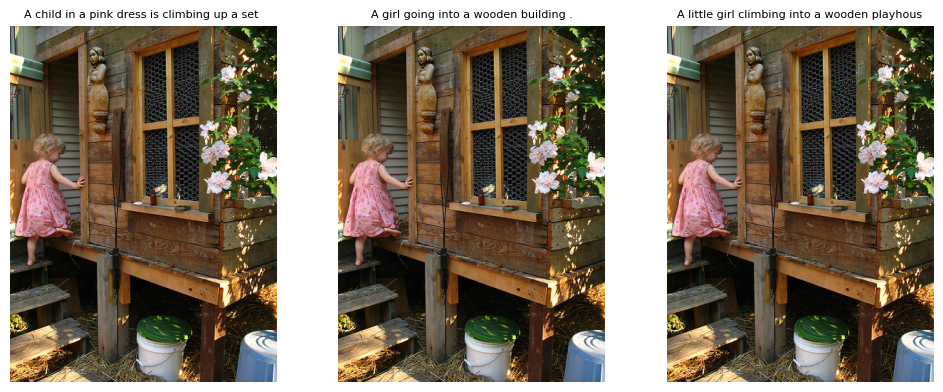

In [28]:
def split_by_image(records, selected_images, val_images=None, val_ratio=0.1, seed=42):
    shuffled_images = list(selected_images)
    random.Random(seed).shuffle(shuffled_images)
    if val_images is None:
        val_images = max(1, int(len(shuffled_images) * val_ratio))
    val_images = min(val_images, max(1, len(shuffled_images) - 1))
    val_set = set(shuffled_images[:val_images])
    train_records = [item for item in records if item['image_name'] not in val_set]
    val_records = [item for item in records if item['image_name'] in val_set]
    return train_records, val_records


train_records, val_records = split_by_image(
    records,
    selected_images,
    val_images=CONFIG['val_images'],
    val_ratio=CONFIG['val_ratio'],
    seed=42,
)
print('Train captions:', len(train_records))
print('Val captions:', len(val_records))

plt.figure(figsize=(10, 4))
for i, item in enumerate(train_records[:3]):
    image = Image.open(item['image_path']).convert('RGB')
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(item['caption'][:45], fontsize=8)
plt.tight_layout()

## 3. Dataset 和 DataLoader

In [29]:
image_processor = CLIPImageProcessor.from_pretrained(CONFIG['vision_model'])
tokenizer = AutoTokenizer.from_pretrained(CONFIG['language_model'])

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


class FlickrCaptionDataset(Dataset):
    def __init__(self, records, image_processor, tokenizer, max_text_length=40):
        self.records = records
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_text_length = max_text_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        item = self.records[index]
        image = Image.open(item['image_path']).convert('RGB')
        pixel_values = self.image_processor(images=image, return_tensors='pt')['pixel_values'][0]
        tokenized = self.tokenizer(
            item['caption'],
            padding='max_length',
            truncation=True,
            max_length=self.max_text_length,
            return_tensors='pt',
        )
        return {
            'pixel_values': pixel_values,
            'input_ids': tokenized['input_ids'][0],
            'attention_mask': tokenized['attention_mask'][0],
            'caption': item['caption'],
            'image_name': item['image_name'],
        }


train_dataset = FlickrCaptionDataset(train_records, image_processor, tokenizer, CONFIG['max_text_length'])
val_dataset = FlickrCaptionDataset(val_records, image_processor, tokenizer, CONFIG['max_text_length'])

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
)

batch = next(iter(train_loader))
print(batch['pixel_values'].shape, batch['input_ids'].shape, batch['attention_mask'].shape)

torch.Size([2, 3, 224, 224]) torch.Size([2, 48]) torch.Size([2, 48])


## 4. Mini-BLIP2 模型

结构对应作业要求：

```text
Image -> Frozen CLIP Vision Encoder -> Mini Q-Former -> Projection -> Frozen OPT Decoder -> Caption
```

训练时只更新 query tokens、Mini Q-Former、视觉到 Q-Former 的投影层、Q-Former 到 OPT embedding 空间的投影层。

In [30]:
class MiniQFormer(nn.Module):
    def __init__(self, num_query_tokens=16, qformer_dim=256, num_layers=2, num_heads=8, vision_dim=768):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_query_tokens, qformer_dim) * 0.02)
        self.vision_to_q = nn.Linear(vision_dim, qformer_dim)
        self.layers = nn.ModuleList([
            nn.TransformerDecoderLayer(
                d_model=qformer_dim,
                nhead=num_heads,
                dim_feedforward=qformer_dim * 4,
                dropout=0.1,
                batch_first=True,
                norm_first=True,
            )
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(qformer_dim)

    def forward(self, image_features):
        memory = self.vision_to_q(image_features)
        queries = self.query_tokens.expand(image_features.size(0), -1, -1)
        for layer in self.layers:
            queries = layer(tgt=queries, memory=memory)
        return self.norm(queries)


class MiniBLIP2(nn.Module):
    def __init__(self, config, tokenizer):
        super().__init__()
        self.tokenizer = tokenizer
        self.vision_encoder = CLIPVisionModel.from_pretrained(config['vision_model'])
        self.language_model = OPTForCausalLM.from_pretrained(config['language_model'])

        vision_dim = self.vision_encoder.config.hidden_size
        lm_dim = self.language_model.config.hidden_size

        self.qformer = MiniQFormer(
            num_query_tokens=config['num_query_tokens'],
            qformer_dim=config['qformer_dim'],
            num_layers=config['qformer_layers'],
            num_heads=config['qformer_heads'],
            vision_dim=vision_dim,
        )
        self.q_to_lm = nn.Linear(config['qformer_dim'], lm_dim)
        self.caption_prompt = config.get('caption_prompt', 'A photo of')

        for param in self.vision_encoder.parameters():
            param.requires_grad = False
        for param in self.language_model.parameters():
            param.requires_grad = False

    def encode_image_prefix(self, pixel_values):
        with torch.no_grad():
            vision_outputs = self.vision_encoder(pixel_values=pixel_values)
            image_features = vision_outputs.last_hidden_state
        q_outputs = self.qformer(image_features)
        return self.q_to_lm(q_outputs)

    def _make_prompt_embeds(self, batch_size, device):
        prompt_ids = self.tokenizer(
            self.caption_prompt,
            return_tensors='pt',
            add_special_tokens=False,
        ).input_ids.to(device)
        prompt_ids = prompt_ids.expand(batch_size, -1)
        return self.language_model.get_input_embeddings()(prompt_ids)

    def forward(self, pixel_values, input_ids, attention_mask):
        prefix_embeds = self.encode_image_prefix(pixel_values)
        prompt_embeds = self._make_prompt_embeds(input_ids.size(0), input_ids.device)
        token_embeds = self.language_model.get_input_embeddings()(input_ids)

        inputs_embeds = torch.cat([prefix_embeds, prompt_embeds, token_embeds], dim=1)

        prefix_mask = torch.ones(prefix_embeds.shape[:2], dtype=attention_mask.dtype, device=attention_mask.device)
        prompt_mask = torch.ones(prompt_embeds.shape[:2], dtype=attention_mask.dtype, device=attention_mask.device)
        full_attention_mask = torch.cat([prefix_mask, prompt_mask, attention_mask], dim=1)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        prefix_labels = torch.full(prefix_embeds.shape[:2], -100, dtype=torch.long, device=input_ids.device)
        prompt_labels = torch.full(prompt_embeds.shape[:2], -100, dtype=torch.long, device=input_ids.device)
        labels = torch.cat([prefix_labels, prompt_labels, labels], dim=1)

        return self.language_model(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attention_mask,
            labels=labels,
        )


In [31]:
model = MiniBLIP2(CONFIG, tokenizer).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params / 1e6:.2f}M')
print(f'Trainable params: {trainable_params / 1e6:.2f}M')

for name, param in model.named_parameters():
    if param.requires_grad:
        print('trainable:', name, tuple(param.shape))

Total params: 215.20M
Trainable params: 2.51M
trainable: qformer.query_tokens (1, 16, 256)
trainable: qformer.vision_to_q.weight (256, 768)
trainable: qformer.vision_to_q.bias (256,)
trainable: qformer.layers.0.self_attn.in_proj_weight (768, 256)
trainable: qformer.layers.0.self_attn.in_proj_bias (768,)
trainable: qformer.layers.0.self_attn.out_proj.weight (256, 256)
trainable: qformer.layers.0.self_attn.out_proj.bias (256,)
trainable: qformer.layers.0.multihead_attn.in_proj_weight (768, 256)
trainable: qformer.layers.0.multihead_attn.in_proj_bias (768,)
trainable: qformer.layers.0.multihead_attn.out_proj.weight (256, 256)
trainable: qformer.layers.0.multihead_attn.out_proj.bias (256,)
trainable: qformer.layers.0.linear1.weight (1024, 256)
trainable: qformer.layers.0.linear1.bias (1024,)
trainable: qformer.layers.0.linear2.weight (256, 1024)
trainable: qformer.layers.0.linear2.bias (256,)
trainable: qformer.layers.0.norm1.weight (256,)
trainable: qformer.layers.0.norm1.bias (256,)
trai

## 5. 训练与验证

In [32]:
def move_batch_to_device(batch, device):
    return {
        'pixel_values': batch['pixel_values'].to(device),
        'input_ids': batch['input_ids'].to(device),
        'attention_mask': batch['attention_mask'].to(device),
    }


optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)

num_update_steps = len(train_loader) * CONFIG['epochs']
if CONFIG['max_steps'] is not None:
    num_update_steps = min(num_update_steps, CONFIG['max_steps'])
print('Planned update steps:', num_update_steps)

Planned update steps: 18205


In [33]:
def train_one_epoch(model, loader, optimizer, device, max_steps=None):
    model.train()
    losses = []
    progress = tqdm(loader, desc='train')
    for step, batch in enumerate(progress, start=1):
        batch_on_device = move_batch_to_device(batch, device)
        outputs = model(**batch_on_device)
        loss = outputs.loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()

        losses.append(loss.item())
        progress.set_postfix(loss=f'{loss.item():.4f}', avg=f'{sum(losses) / len(losses):.4f}')

        if max_steps is not None and step >= max_steps:
            break
    return sum(losses) / max(1, len(losses)), losses


@torch.no_grad()
def evaluate_loss(model, loader, device, max_batches=20):
    model.eval()
    losses = []
    for step, batch in enumerate(tqdm(loader, desc='val'), start=1):
        batch_on_device = move_batch_to_device(batch, device)
        outputs = model(**batch_on_device)
        losses.append(outputs.loss.item())
        if step >= max_batches:
            break
    return sum(losses) / max(1, len(losses))

In [34]:
history = {'train_loss': [], 'val_loss': [], 'step_loss': []}

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss, step_losses = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device,
        max_steps=CONFIG['max_steps'],
    )
    val_loss = evaluate_loss(model, val_loader, device)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['step_loss'].extend(step_losses)
    print(f'Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
    'history': history,
}, CONFIG['checkpoint_path'])
print('Saved checkpoint to:', CONFIG['checkpoint_path'])

train:   0%|          | 0/18205 [00:00<?, ?it/s]

val:   0%|          | 0/2023 [00:00<?, ?it/s]

Epoch 1: train_loss=2.7045, val_loss=2.1191
Saved checkpoint to: E:\program_prject\vscode_python_project\论文复现\blip2-main\blip2-main\code\outputs\mini_blip2_flickr8k.pt


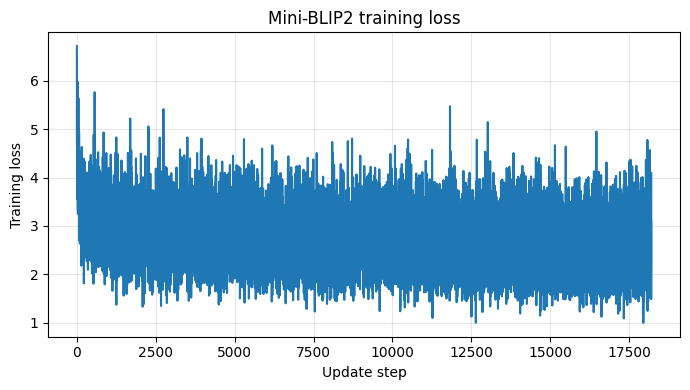

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(history['step_loss'])
plt.xlabel('Update step')
plt.ylabel('Training loss')
plt.title('Mini-BLIP2 training loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'loss_curve.png', dpi=160)
plt.show()

## 6. 训练记录说明

运行完成后，关键训练输出会保存在 `code/outputs/`：

- `mini_blip2_flickr8k.pt`：训练后的 checkpoint
- `loss_curve.png`：loss 曲线

训练 notebook 只负责训练、验证 loss、保存 checkpoint 和绘制 loss 曲线。生成 caption 与结果图展示请运行 `code/test.ipynb`，测试输出保存为 `code/outputs/test_generation_examples.png`。

报告中可以说明：本实验冻结了 `openai/clip-vit-base-patch32` 和 `facebook/opt-125m`，只训练 Mini Q-Former 与投影层，测试阶段单独从 checkpoint 加载模型进行 caption 生成。